In [285]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import equilibrium_critical_correlations as eq
from common_imports import *

r_max = 100
n_values = [1,2,3,4]
folder = "data/"
tau_filenames = [folder+f"data_Pn_corr_n{n}_rmax{r_max}.npz" for n in n_values]
critical_corr_filenames = [folder+f"critical_correlation_n{n}_rmax{r_max}.npz.npy" for n in n_values]
r= np.load(tau_filenames[0])["r"]
taus = np.load(folder+"data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['taus']
states= np.load(folder+"data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['states']
states2=np.load(folder+"data_KZ_L500_t_tau_N100_tau1.0e-03-3.2e+03.npz")['states']
PP_quenched = ([np.load(filename)['PP_corr'] for filename in tau_filenames])
crit = ([np.load(filename) for filename in critical_corr_filenames])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


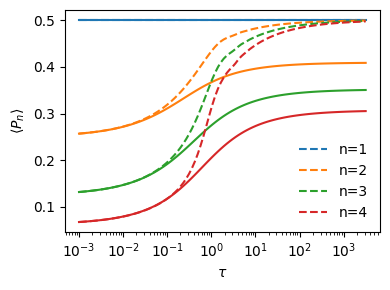

In [286]:
plt.figure(figsize=(4, 3))
colors = [f"C{i}" for i in range(len(n_values))]

for i, n in enumerate(n_values):
    vals1 = np.array([kz.P_n(n, s) for s in states])
    vals2 = np.array([kz.P_n(n, s) for s in states2])
    plt.plot(taus, vals1, color=colors[i])
    plt.plot(taus, vals2, "--", color=colors[i], label=f"n={n}")

plt.xscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_n\rangle$")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("Fellowship_figure_2.png")
plt.show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_7491/3137185204.py:4: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-1/4)/6,"--k",label=r"$r^{-1/4}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_7491/3137185204.py:4: RuntimeWarning: invalid value encountered in power
  plot(r,r**(-1/4)/6,"--k",label=r"$r^{-1/4}$")


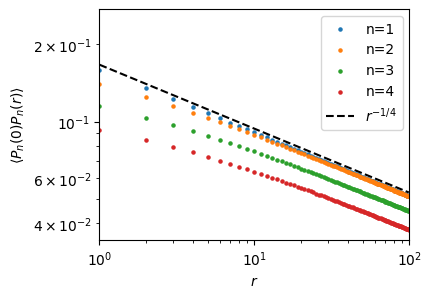

In [287]:
plt.figure(figsize=(4,3))
for n,c in enumerate(crit):
    scatter(r,c,s=5,label=f"n={n+1}")
plot(r,r**(-1/4)/6,"--k",label=r"$r^{-1/4}$")
loglog()
legend()
ylabel(r"$\langle{P_n(0)P_n(r)} \rangle$")
xlabel(r"$r$")
xlim(1,100)
plt.savefig("Fellowship_figure_1")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_7491/4025973067.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  variance_all[i, j] = num / den if den != 0 else np.nan


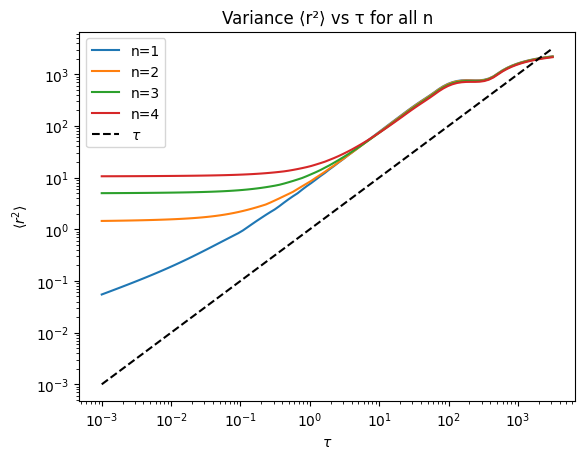

In [288]:
r2 = r ** 2
variance_all = np.zeros((len(n_values), len(taus)))

for i in range(len(n_values)):        # loop over n
    for j in range(len(taus)):        # loop over tau
        vals = PP_quenched[i][j]
        num = 0.0
        den = 0.0
        for k in range(len(r)):       # explicit manual loop
            num += abs(r2[k] * vals[k])
            den += vals[k]
        variance_all[i, j] = num / den if den != 0 else np.nan

plt.figure()
for i, n in enumerate(n_values):
    plt.loglog(taus, np.abs(variance_all[i]), label=f"n={n}")
plt.plot(taus, taus, "k--", label=r"$\tau$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle r^2 \rangle$")
plt.legend()
plt.title("Variance ⟨r²⟩ vs τ for all n")
plt.show()

(-0.1, 0.0)

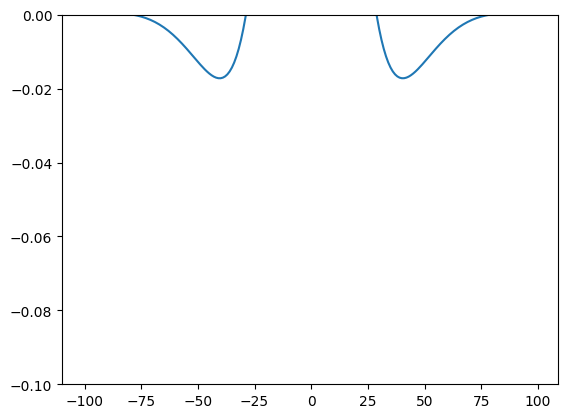

In [289]:
P1 = ([np.load(filename)['PP_corr'] for filename in tau_filenames])[0]
plot(r,4*P1[70])
ylim(-.1,0)

In [290]:
PP_quench_sf = fftshift(fft(PP_quenched, axis=-1), axes=-1)
PP_crit_sf   = fftshift(fft(crit, axis=-1), axes=-1)
k = fftshift(fftfreq(len(r),1))*2*pi
rhos = array([eq.sigma_general([0,1])-kz.sigma_general([0,1],s) for s in states])

In [291]:
# for j in range(len(taus)):
#     [plot(abs(PP_quench_sf[i, j, :])/sum(abs(PP_quench_sf[i, j, :]))) for i in range(4)]
#     show()

from ipywidgets import interact

@interact(j=(0, len(taus)-1))
def plot_quench(j=0):
    plt.figure()
    for i in range(len(n_values)):
        plot(k,taus[j]**(-3/8)*abs(PP_quench_sf[i, j, :]) / sum(abs(PP_quench_sf[i, j, :])), label=f"n={i+1}")
        title(taus[j])
    #ylim(0.0003,.1)
    loglog()
    legend()
    show()


interactive(children=(IntSlider(value=0, description='j', max=99), Output()), _dom_classes=('widget-interact',…

In [292]:
from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt

@interact(j=(0, len(taus)-1))
def plot_quench(j=0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
    widths = []

    # loop dynamically over whatever n_values you defined
    for i, n in enumerate(n_values):
        y = taus[j]**(-3/8) * np.abs(PP_quench_sf[i, j, :]) / np.sum(np.abs(PP_quench_sf[i, j, :]))
        ax1.plot(k, y, label=f"n={n}")

        base = np.min(y)
        peak = np.max(y)
        half = base + 0.5 * (peak - base)

        # find crossings for FWHM
        above = y >= half
        idx = np.where(np.diff(above.astype(int)) != 0)[0]
        if len(idx) >= 2:
            width = abs(k[idx[-1]] - k[idx[0]])
            widths.append(width)
            ax1.axvline(k[idx[0]], color=f"C{i}", ls="--", lw=0.8)
            ax1.axvline(k[idx[-1]], color=f"C{i}", ls="--", lw=0.8)
        else:
            widths.append(np.nan)

    ax1.set_title(fr"$\tau = {taus[j]:.3g}$")
    ax1.set_xlabel("k")
    ax1.set_ylabel(r"$\tau^{-3/8}|S(k)|/\sum|S(k)|$")
    ax1.legend()

    # --- FWHM scatter plot ---
    n_vals = np.array(n_values)
    widths = np.array(widths)
    ax2.scatter(n_vals, 1/widths, c=[f"C{i}" for i in range(len(n_values))], s=40)
    ax2.set_xlabel("n")
    ax2.set_ylabel(r"$1/\mathrm{FWHM}$")
    ax2.set_title("Inverse FWHM vs n")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



interactive(children=(IntSlider(value=0, description='j', max=99), Output()), _dom_classes=('widget-interact',…

In [293]:
from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

@interact(j=(0, len(taus)-1))
def plot_quench_interp(j=0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
    widths = []

    for i, n in enumerate(n_values):
        # interpolation of y(k)
        y_raw = taus[j]**(-3/8) * np.abs(PP_quench_sf[i, j, :]) / np.sum(np.abs(PP_quench_sf[i, j, :]))
        f = interp1d(k, y_raw, kind='cubic')
        k_fine = np.linspace(k.min(), k.max(), 2000)
        y = f(k_fine)

        ax1.plot(k_fine, y, label=f"n={n} (interp)")

        base = np.min(y)
        peak = np.max(y)
        half = base + 0.5 * (peak - base)

        # crossings for FWHM
        above = y >= half
        idx = np.where(np.diff(above.astype(int)) != 0)[0]
        if len(idx) >= 2:
            width = abs(k_fine[idx[-1]] - k_fine[idx[0]])
            widths.append(width)
            ax1.axvline(k_fine[idx[0]], color=f"C{i}", ls="--", lw=0.8)
            ax1.axvline(k_fine[idx[-1]], color=f"C{i}", ls="--", lw=0.8)
        else:
            widths.append(np.nan)

    ax1.set_title(fr"Interpolated $S(k)$ at $\tau = {taus[j]:.3g}$")
    ax1.set_xlabel("k")
    ax1.set_ylabel(r"$\tau^{-3/8}|S(k)|/\sum|S(k)|$")
    ax1.legend()

    n_vals = np.array(n_values)
    widths = np.array(widths)
    ax2.scatter(n_vals, 1/widths, c=[f"C{i}" for i in range(len(n_values))], s=40)
    ax2.set_xlabel("n")
    ax2.set_ylabel(r"$1/\mathrm{FWHM}$")
    ax2.set_title("Interpolation: Inverse FWHM vs n")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=0, description='j', max=99), Output()), _dom_classes=('widget-interact',…

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_7491/2455169401.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,10)


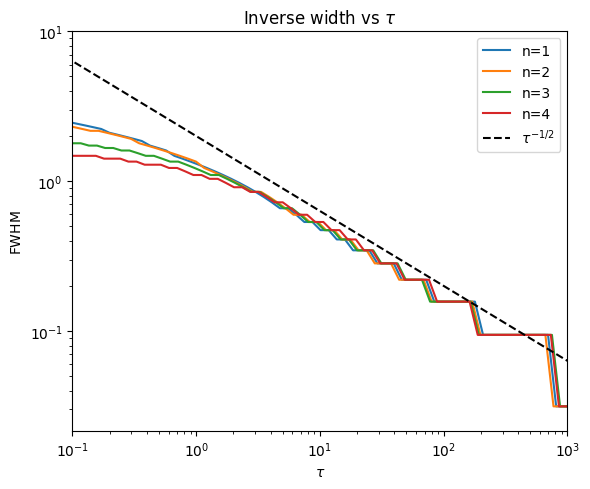

In [301]:
import numpy as np
import matplotlib.pyplot as plt

widths = np.zeros((len(n_values), len(taus)))

for i, n in enumerate(n_values):
    for j, tau in enumerate(taus):
        y = tau**(-3/8) * np.abs(PP_quench_sf[i, j, :])
        y /= np.sum(np.abs(PP_quench_sf[i, j, :]))

        base, peak = np.min(y), np.max(y)
        half = base + 0.5 * (peak - base)
        above = y >= half
        idx = np.where(np.diff(above.astype(int)) != 0)[0]
        if len(idx) >= 2:
            widths[i, j] = abs(k[idx[-1]] - k[idx[0]])
        else:
            widths[i, j] = np.nan

plt.figure(figsize=(6,5))
for i, n in enumerate(n_values):
    plt.plot(taus/n**(1/14), widths[i], label=f"n={n}",ms=2)
plot(taus,2*taus**(-1/2),"--k",label=r"$\tau^{-1/2}$")
plt.xscale("log")
plt.yscale("log")
xlim(10e-2, 10e2)
ylim(0,10)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\mathrm{FWHM}$")
plt.title(r"Inverse width vs $\tau$")
plt.legend()
plt.tight_layout()
plt.show()


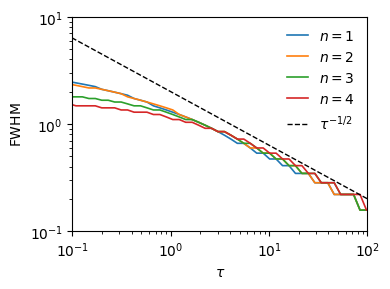

In [306]:
import numpy as np
import matplotlib.pyplot as plt

widths = np.zeros((len(n_values), len(taus)))

for i, n in enumerate(n_values):
    for j, tau in enumerate(taus):
        y = tau**(-3/8) * np.abs(PP_quench_sf[i, j, :])
        y /= np.sum(np.abs(PP_quench_sf[i, j, :]))

        base, peak = np.min(y), np.max(y)
        half = base + 0.5 * (peak - base)
        above = y >= half
        idx = np.where(np.diff(above.astype(int)) != 0)[0]
        if len(idx) >= 2:
            widths[i, j] = abs(k[idx[-1]] - k[idx[0]])
        else:
            widths[i, j] = np.nan

plt.figure(figsize=(4, 3))
colors = [f"C{i}" for i in range(len(n_values))]

for i, n in enumerate(n_values):
    plt.plot(taus , widths[i], color=colors[i], lw=1.2, label=fr"$n={n}$")

plt.plot(taus, 2 * taus**(-1/2), "--k", lw=1, label=r"$\tau^{-1/2}$")

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-1, 1e2)
plt.ylim(1e-1, 10)

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\mathrm{FWHM}$")
plt.legend(frameon=False, handlelength=1.5)
plt.tight_layout()
plt.savefig("Fellowship_figure_6.png")
plt.show()

In [18]:
# def FT(dat):
#     return fftshift(fft(dat))

# k = fftshift(fftfreq(len(r),1))*2*pi
# PP_quench_sf = array([FT(PP) for PP in PP_quenched])
# PP_crit_sf = array([FT(PP) for PP in crit])


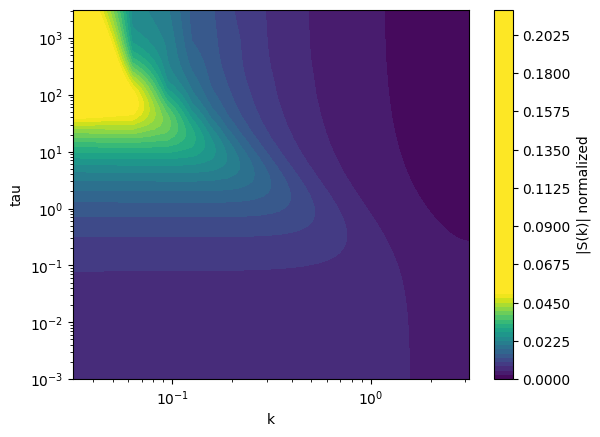

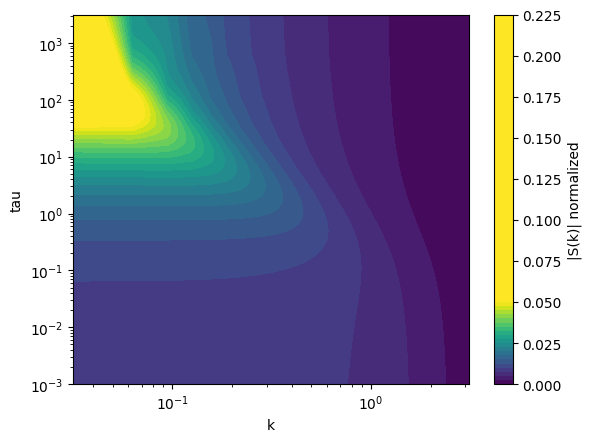

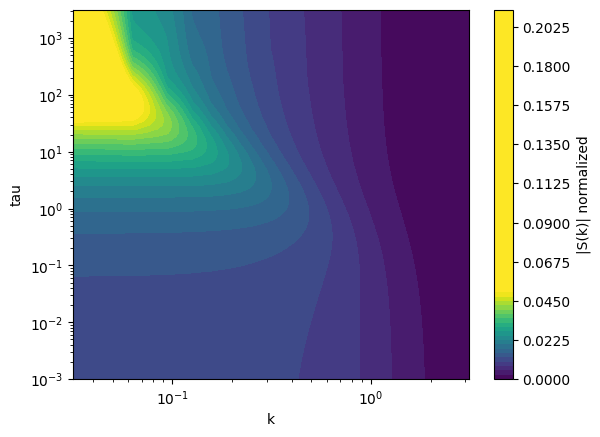

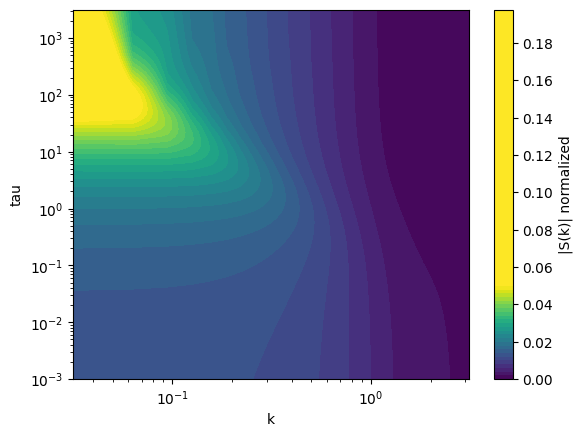

In [6]:
from matplotlib.pyplot import contourf, colorbar

# normalize each slice
normed = abs(PP_quench_sf) / abs(PP_quench_sf).sum(axis=-1, keepdims=True)

# choose n index (e.g., 0)
for n in n_values:
    n_index = n-1
    Z = normed[n_index, :, :]   # shape (len(taus), len(k))

    plt.figure()
    contourf(k, taus, Z, levels=100, vmin=1e-5, vmax=1e-2*5)
    xlim(k[1]-k[0],3.14)
    #ylim(taus[0],taus[50])
    yscale("log")
    xscale("log")
    xlabel("k")
    ylabel("tau")
    colorbar(label="|S(k)| normalized")

In [ ]:
idx = np.argmin(np.abs(k))


np.int64(100)

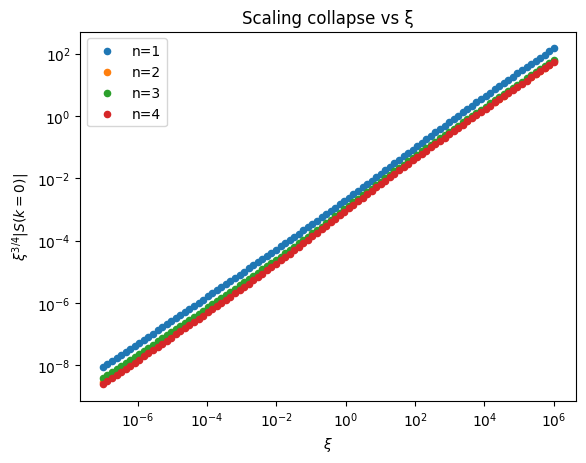

In [61]:
plt.figure()
colors = [f"C{i}" for i in range(len(n_values))]
for i, n in enumerate(n_values):
    x_scaled = []
    y_scaled = []
    for j, tau in enumerate(taus):
        xi = 1/ tau/tau#(rhos[j])
        val = abs(PP_quench_sf[i, j, 10])
        norm = np.sum(abs(PP_quench_sf[i, j, :]))
        S_scaled = (xi)**(+3/4) * val / norm 
        x_scaled.append(xi)
        y_scaled.append(S_scaled)

    plt.scatter(x_scaled, y_scaled, s=20, color=colors[i], label=f"n={n}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\xi$")
plt.ylabel(r"$\xi^{3/4}|S(k{=}0)|$")
plt.title("Scaling collapse vs ξ")
plt.legend()
plt.show()


/tmp/ipykernel_22614/2503437917.py:6: RuntimeWarning: divide by zero encountered in power
  plt.plot(scaled_k,scaled_k**(-3/4)/6,"--k")
/tmp/ipykernel_22614/2503437917.py:6: RuntimeWarning: invalid value encountered in power
  plt.plot(scaled_k,scaled_k**(-3/4)/6,"--k")


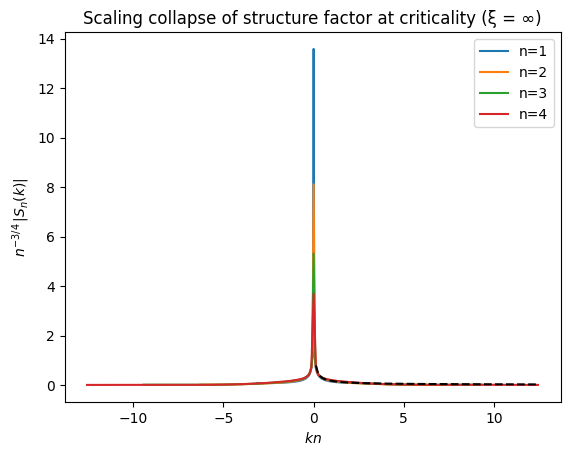

In [345]:
plt.figure()
for i, n in enumerate(n_values):
    scaled_k = k * n
    scaled_S = abs(PP_crit_sf[i]) * n**(-3/4)
    plt.plot(scaled_k, scaled_S, label=f"n={n}")
plt.plot(scaled_k,scaled_k**(-3/4)/6,"--k")
#plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"$k n$")
plt.ylabel(r"$n^{-3/4}\,|S_n(k)|$")
plt.title("Scaling collapse of structure factor at criticality (ξ = ∞)")
plt.legend()
plt.show()


/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


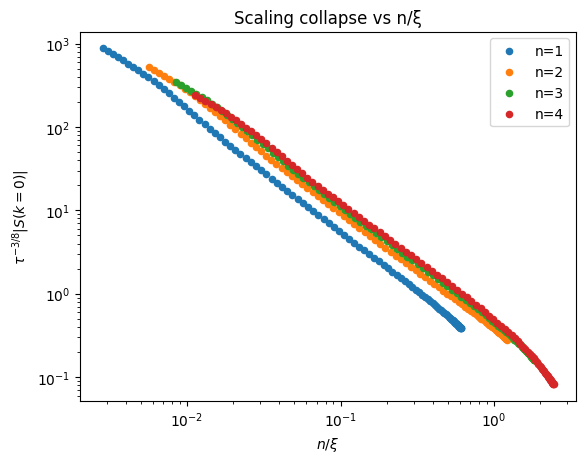

In [210]:
# Assume n_list = [1, 2, 3, 4]
k0_index = np.argmin(abs(k))
colors = ["C0", "C1", "C2", "C3"]

plt.figure()
for i, n in enumerate(n_values):
    x_scaled = []
    y_scaled = []
    for j, tau in enumerate(taus):
        xi = 1/rhos[j]
        val = abs(PP_quench_sf[i, j, k0_index])
        norm = sum(abs(PP_quench_sf[i, j, :]))
        S_scaled = ((xi/n)**(3/4))*val
        x_scaled.append(n/xi)
        y_scaled.append(S_scaled)

    plt.scatter(x_scaled, y_scaled, s=20, color=colors[i], label=f"n={n}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$n/\xi$")
plt.ylabel(r"$\tau^{-3/8}|S(k{=}0)|$")
plt.title("Scaling collapse vs n/ξ")
plt.legend()
plt.show()

I am trying to investigate the function 

$$S(k;n) = \xi^{-3/4} g(k,\xi,n)$$

/tmp/ipykernel_22614/1128992831.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  data[i, j] = xi**(3/4) * val   # this is g(k0, xi, n)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/transforms.py:988: ComplexWarning: Casting complex values to real discards the imaginary part
  self._points[:, 0] = interval


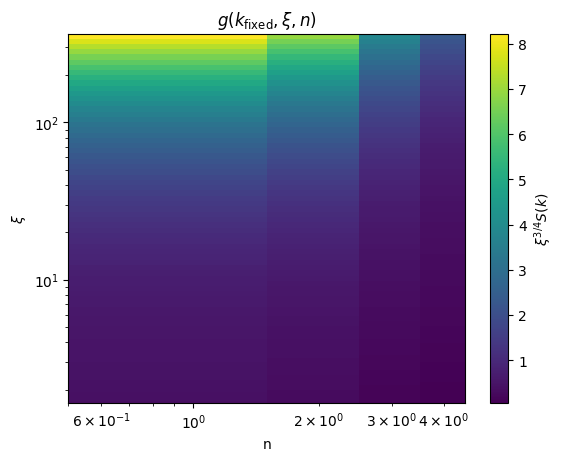

In [249]:
# k0: fixed momentum index
k0_index = np.argmin(abs(k - pi/2))   # choose k_target (e.g., 0 or small value)

# compute S(k0, n, xi) * xi^{3/4}
data = np.zeros((len(n_values), len(taus)))
for i, n in enumerate(n_values):
    for j, tau in enumerate(taus):
        xi = 1 / rhos[j]
        val = abs(PP_quench_sf[i, j, k0_index])
        data[i, j] = xi**(3/4) * val   # this is g(k0, xi, n)

# create 2D mesh
N, XI = np.meshgrid(n_values, 1 / rhos)  # axes: n and xi

# plot
plt.figure()
pcm = plt.pcolormesh(N, XI, data.T, shading="auto")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n")
plt.ylabel(r"$\xi$")
plt.title(r"$g(k_{\mathrm{fixed}}, \xi, n)$")
plt.colorbar(pcm, label=r"$\xi^{3/4}S(k)$")
plt.show()


In [269]:
from ipywidgets import interact

@interact(xi_index=(0, len(rhos)-1))
def plot_g_fixed_xi(xi_index=0):
    xi_fixed = 1 / rhos[xi_index]

    data = np.zeros((len(n_values), len(k)))
    for i, n in enumerate(n_values):
        spec = abs(PP_quench_sf[i, xi_index, :])
        norm = np.sum(spec)
        data[i, :] = (spec / norm) * xi_fixed**(3/4)

    N, K = np.meshgrid(n_values, k)

    plt.figure()
    pcm = plt.pcolormesh(N, K, data.T, shading="auto",vmin=0,vmax=.2)
    yscale("log")
    plt.xlabel("n")
    ylim(k[1]-k[0],pi)
    plt.ylabel("k")
    plt.title(fr"$g(k,n)$ normalized, fixed $\xi={xi_fixed:.3g}$")
    plt.colorbar(pcm, label=r"$\xi^{3/4} S(k) / \sum_k S(k)$")
    plt.show()


interactive(children=(IntSlider(value=0, description='xi_index', max=99), Output()), _dom_classes=('widget-int…

In [ ]:
from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt

@interact(n_index=(0, len(n_values)-1))
def plot_g_fixed_n(n_index=0):
    n_fixed = n_values[n_index]

    # initialize clean float array
    data = np.zeros((len(rhos), len(k)), dtype=np.float64)

    for j, rho in enumerate(rhos):
        xi = float(np.real_if_close(1.0 / rho))
        spec_complex = PP_quench_sf[n_index, j, :]

        # absolute magnitude, force real float
        spec = np.abs(np.asarray(spec_complex)).astype(np.float64)
        norm = float(np.sum(spec))
        if norm == 0:
            norm = 1.0

        data[j, :] = (spec / norm) * (n_fixed/xi)**-0.75

    # now all data are real
    data = np.nan_to_num(np.real(data), nan=0.0).astype(np.float64)
    XI = np.real(1.0 / np.asarray(rhos, dtype=np.complex128)).astype(np.float64)/n_fixed
    K = np.real(np.asarray(k, dtype=np.complex128)).astype(np.float64)
    XI_grid, K_grid = np.meshgrid(XI, K, indexing="ij")

    plt.figure()
    pcm = plt.pcolormesh(
        XI_grid, K_grid, data, shading="auto", vmin=0.0, vmax=0.25
    )
    plt.xlabel(r"$\xi$")
    plt.ylabel("k")
    ylim(-3,3)
    plt.title(fr"$g(k,\xi,n)$ normalized, fixed $n={n_fixed}$")
    plt.colorbar(pcm, label=r"$\xi^{3/4} S(k) / \sum_k S(k)$")
    plt.show()



interactive(children=(IntSlider(value=0, description='n_index', max=3), Output()), _dom_classes=('widget-inter…

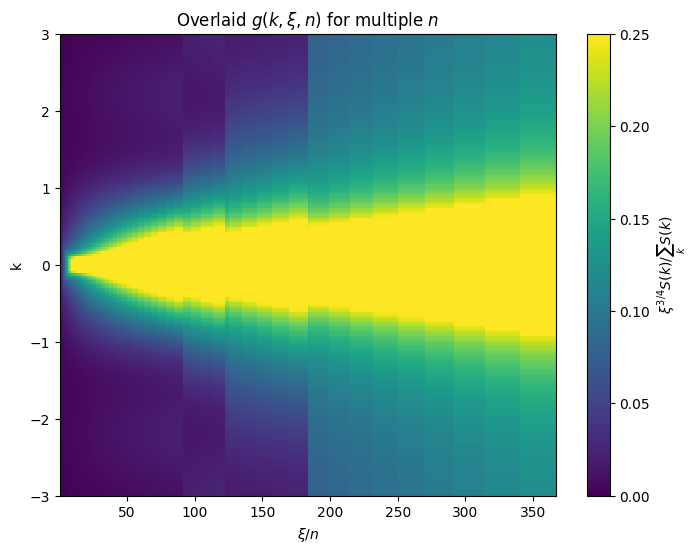

In [305]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for n_index, n_fixed in enumerate(n_values):
    # build real float data
    data = np.zeros((len(rhos), len(k)), dtype=float)
    for j, rho in enumerate(rhos):
        xi = float(np.real_if_close(1.0 / rho))
        spec = np.abs(PP_quench_sf[n_index, j, :]).astype(float)
        norm = np.sum(spec)
        if norm == 0:
            norm = 1.0
        data[j, :] = (spec / norm) * (n_fixed/xi)**(-0.75)

    # coordinate grids
    XI = np.real(1.0 / np.asarray(rhos)).astype(float) / n_fixed
    K  = np.real(np.asarray(k)).astype(float)
    XI_grid, K_grid = np.meshgrid(XI, K, indexing="ij")

    # overlay with transparency
    pcm = plt.pcolormesh(
        XI_grid, K_grid, data,
        shading="auto", vmin=0.0, vmax=0.25,
        alpha=1, label=f"n={n_fixed}"
    )

plt.xlabel(r"$\xi/n$")
plt.ylabel("k")
plt.ylim(-3, 3)
plt.title(r"Overlaid $g(k,\xi,n)$ for multiple $n$")
cbar = plt.colorbar(pcm)
cbar.set_label(r"$\xi^{3/4} S(k)/\sum_k S(k)$")
plt.show()


/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


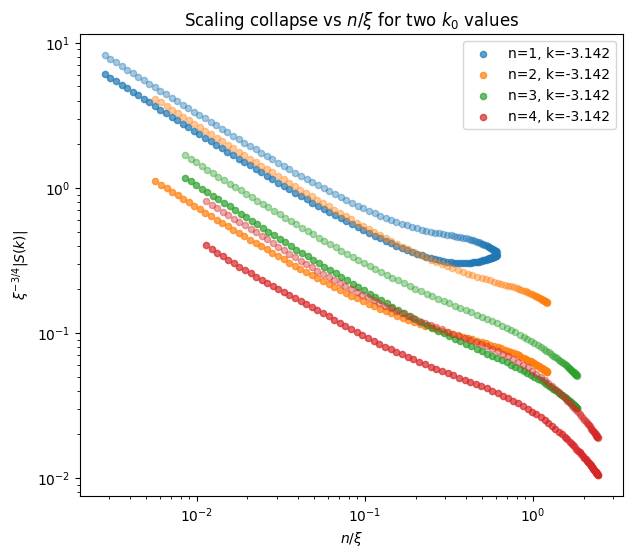

In [307]:
# Example: choose two target k values
k0_targets = [k[0], k[len(k)//4]]  # or any two specific points
colors = ["C0", "C1", "C2", "C3"]

plt.figure(figsize=(7,6))

for kidx, k0_target in enumerate(k0_targets):
    k0_index = np.argmin(abs(k - k0_target))

    for i, n in enumerate(n_values):
        x_scaled, y_scaled = [], []
        for j, tau in enumerate(taus):
            xi = 1 / rhos[j]
            val = abs(PP_quench_sf[i, j, k0_index])
            norm = sum(abs(PP_quench_sf[i, j, :]))
            S_scaled = ((xi / n) ** (3 / 4)) * val
            x_scaled.append(n / xi)
            y_scaled.append(S_scaled)

        label = f"n={n}, k={k0_target:.3f}" if kidx == 0 else None
        plt.scatter(
            x_scaled, y_scaled, s=20, color=colors[i],
            alpha=0.7 if kidx == 0 else 0.4, label=label
        )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$n/\xi$")
plt.ylabel(r"$\xi^{-3/4}|S(k)|$")
plt.title(r"Scaling collapse vs $n/\xi$ for two $k_0$ values")
plt.legend()
plt.show()


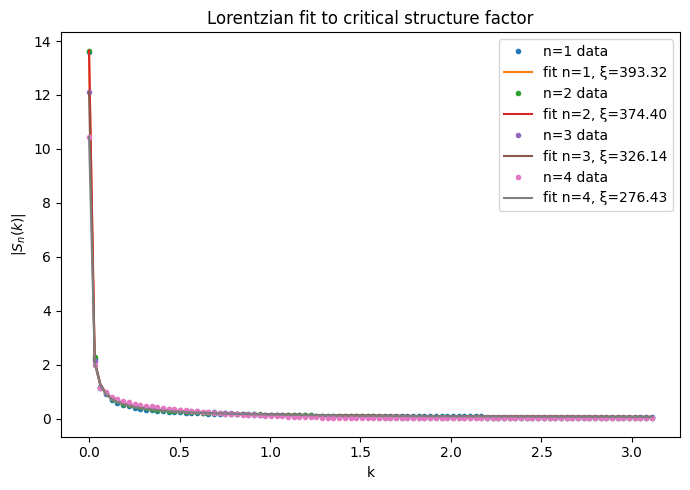

n=1: S0=13.58, xi=393.3
n=2: S0=13.64, xi=374.4
n=3: S0=12.12, xi=326.1
n=4: S0=10.45, xi=276.4


In [347]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def lorentzian(k, S0, xi):
    return S0 / (1 + (xi * k)**2)**(3/8)

plt.figure(figsize=(7,5))

fit_params = []
for i, n in enumerate(n_values):
    y = np.abs(PP_crit_sf[i])
    x = k

    # restrict to positive k to avoid double counting
    mask = x >= 0
    x_fit, y_fit = x[mask], y[mask]

    # initial guesses
    p0 = [y_fit[0], 1.0]

    popt, _ = curve_fit(lorentzian, x_fit, y_fit, p0=p0)
    S0, xi = popt
    fit_params.append((S0, xi))

    plt.plot(x_fit, y_fit, 'o', ms=3, label=f"n={n} data")
    plt.plot(x_fit, lorentzian(x_fit, *popt), '-', label=f"fit n={n}, ξ={xi:.2f}")

plt.xlabel("k")
plt.ylabel(r"$|S_n(k)|$")
plt.title("Lorentzian fit to critical structure factor")
plt.legend()
plt.tight_layout()
plt.show()

for i, n in enumerate(n_values):
    print(f"n={n}: S0={fit_params[i][0]:.4g}, xi={fit_params[i][1]:.4g}")


In [283]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

fit_xi = np.zeros((len(n_values), len(taus)))
fit_S0 = np.zeros((len(n_values), len(taus)))

for i, n in enumerate(n_values):
    for j, tau in enumerate(taus):
        x = np.array(k)
        y = np.abs(PP_quench_sf[i, j, :])   # unscaled spectrum

        # restrict to positive k for stability
        mask = x >= 0
        x_fit, y_fit = x[mask], y[mask]
        if np.all(y_fit == 0):
            fit_S0[i, j], fit_xi[i, j] = np.nan, np.nan
            continue

        try:
            p0 = [y_fit[0], 1.0]  # initial guess S0, xi
            popt, _ = curve_fit(lorentzian, x_fit, y_fit, p0=p0, maxfev=10000)
            fit_S0[i, j], fit_xi[i, j] = popt
        except RuntimeError:
            fit_S0[i, j], fit_xi[i, j] = np.nan, np.nan

# --- Plot ξ vs τ for each n ---
plt.figure(figsize=(8,6))
for i, n in enumerate(n_values):
    plt.plot(taus, fit_xi[i], "o-", label=f"n={n}")
plot(taus,2*pi*taus**(1/2),"--k")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"Fitted $\xi$")
plt.title(r"Fitted correlation length $\xi(\tau)$ from $S_n(k,\tau)$")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'lorentzian' is not defined

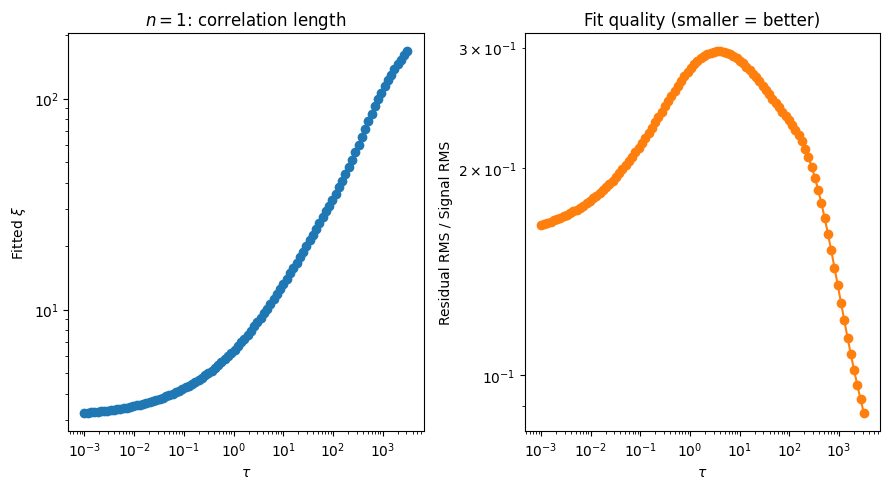

Mean relative residual = 0.216


In [351]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

i = 3  # n = 1
xi_fit = []
S0_fit = []
fit_quality = []

for j, tau in enumerate(taus):
    x = np.array(k)
    y = np.abs(PP_quench_sf[i, j, :])
    mask = x >= 0
    x_fit, y_fit = x[mask], y[mask]

    if np.all(y_fit == 0):
        xi_fit.append(np.nan)
        S0_fit.append(np.nan)
        fit_quality.append(np.nan)
        continue

    try:
        popt, _ = curve_fit(lorentzian, x_fit, y_fit,
                            p0=[y_fit[0], 1.0], maxfev=10000)
        S0, xi = popt
        xi_fit.append(xi)
        S0_fit.append(S0)

        # quality metric: root-mean-square residual / RMS signal
        residual = y_fit - lorentzian(x_fit, *popt)
        rms_res = np.sqrt(np.mean(residual**2))
        rms_sig = np.sqrt(np.mean(y_fit**2))
        fit_quality.append(rms_res / rms_sig)
    except RuntimeError:
        xi_fit.append(np.nan)
        S0_fit.append(np.nan)
        fit_quality.append(np.nan)

# --- Plots ---
plt.figure(figsize=(9,5))
plt.subplot(1,2,1)
plt.plot(taus, xi_fit, "o-", color="C0")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"Fitted $\xi$")
plt.title(r"$n=1$: correlation length")

plt.subplot(1,2,2)
plt.plot(taus, fit_quality, "o-", color="C1")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel("Residual RMS / Signal RMS")
plt.title("Fit quality (smaller = better)")

plt.tight_layout()
plt.show()

print(f"Mean relative residual = {np.nanmean(fit_quality):.3g}")


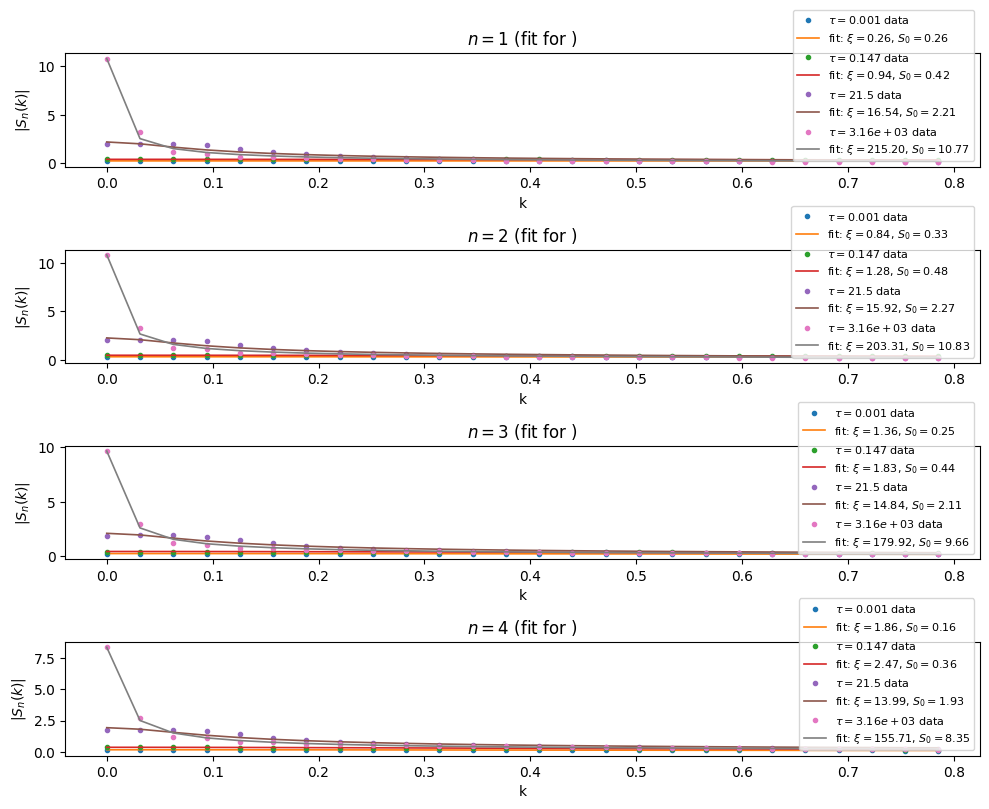

In [358]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

taus_to_show = [taus[0], taus[len(taus)//3], taus[2*len(taus)//3], taus[-1]]

plt.figure(figsize=(10,8))

for i, n in enumerate(n_values):
    for jj, tau_target in enumerate(taus_to_show):
        j = np.argmin(np.abs(taus - tau_target))
        x = np.array(k)
        y = np.abs(PP_quench_sf[i, j, :])

        # restrict to 0 <= k <= π/2
        mask = (x >= 0) & (x <= np.pi/4)
        x_fit, y_fit = x[mask], y[mask]

        try:
            popt, _ = curve_fit(lorentzian, x_fit, y_fit,
                                p0=[y_fit[0], 1.0], maxfev=10000)
            S0, xi = popt
            y_fit_model = lorentzian(x_fit, *popt)
        except RuntimeError:
            S0, xi = np.nan, np.nan
            y_fit_model = np.zeros_like(x_fit)

        plt.subplot(len(n_values), 1, i+1)
        plt.plot(x_fit, y_fit, "o", ms=3,
                 label=rf"$\tau={tau_target:.3g}$ data")
        plt.plot(x_fit, y_fit_model, "-", lw=1.2,
                 label=rf"fit: $\xi={xi:.2f}$, $S_0={S0:.2f}$")

    plt.title(rf"$n={n}$ (fit for )")
    plt.xlabel("k")
    plt.ylabel(r"$|S_n(k)|$")
    plt.legend(fontsize=8)
    plt.tight_layout()

#plt.suptitle(r"Lorentzian fits vs data ($k \le \pi/2$)", y=1.02)
plt.show()


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


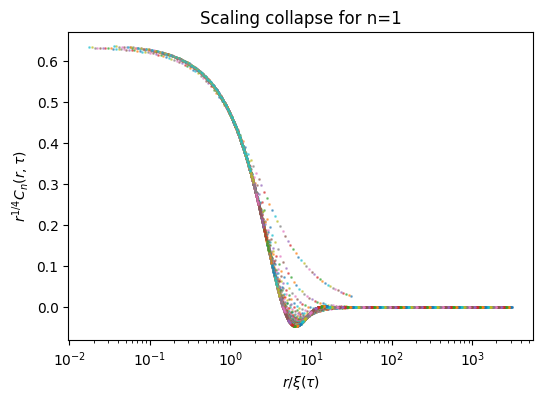

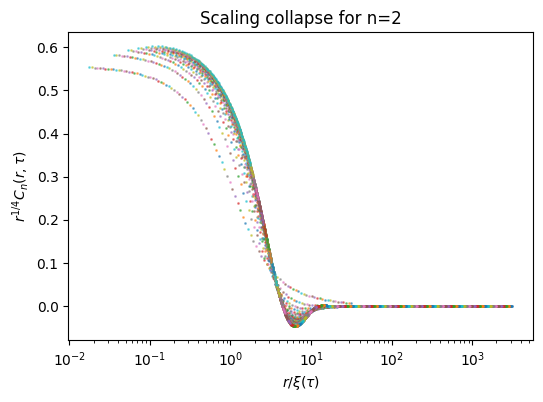

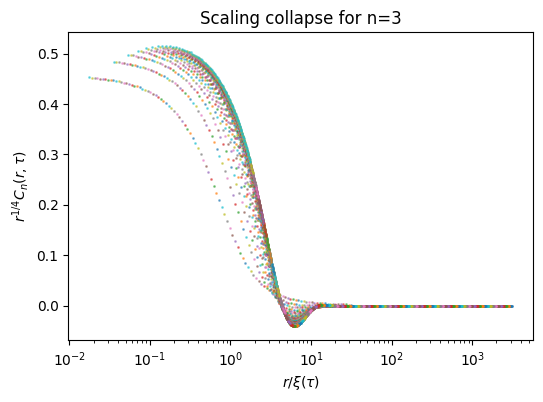

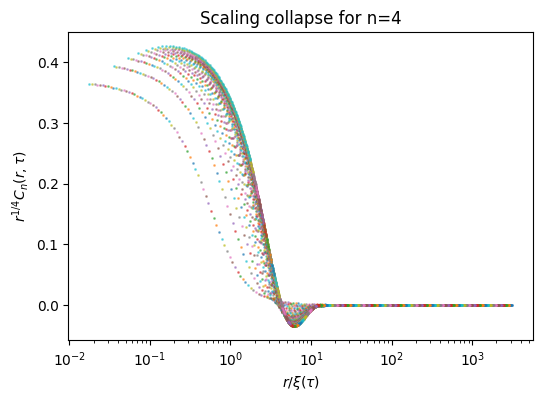

In [202]:
import numpy as np
import matplotlib.pyplot as plt

# params[n][:,2] holds b(τ) ≈ ξ(τ)
xi = {n: params[n][:, 2] for n in n_values}  # from your fit results

mask = r > 0
r_pos = r[mask]

for n, filename in zip(n_values, tau_filenames):
    Pn = np.load(filename)["PP_corr"]
    plt.figure(figsize=(6,4))
    for i, tau in enumerate(taus):
        xi_tau = tau**(1/2)
        y = 4 * Pn[i][mask]
        plt.plot(r_pos/xi_tau, r_pos**(1/4)*y, '.', ms=2, alpha=0.5)
    plt.xscale("log")
    plt.xlabel(r"$r/\xi(\tau)$")
    plt.ylabel(r"$r^{1/4}C_n(r,\tau)$")
    plt.title(f"Scaling collapse for n={n}")
    plt.show()


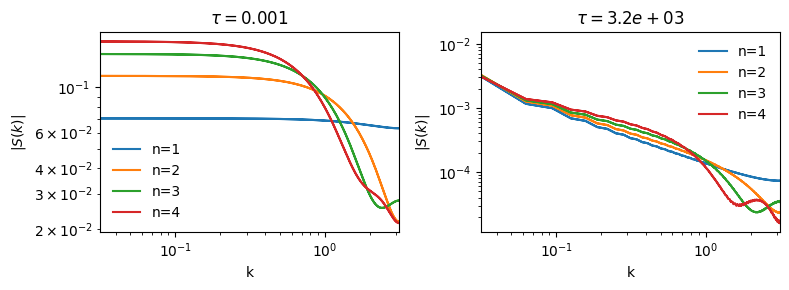

In [307]:
tau_small, tau_large = taus[0], taus[-1]
idx_small = 0
idx_large = len(taus) - 1

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
colors = [f"C{i}" for i in range(len(n_values))]

for ax, j, title in zip(axes, [idx_small, idx_large],
                        [fr"$\tau = {tau_small:.2g}$", fr"$\tau = {tau_large:.2g}$"]):
    for i, n in enumerate(n_values):
        y = taus[j]**(-3/8) * np.abs(PP_quench_sf[i, j, :]) / np.sum(np.abs(PP_quench_sf[i, j, :]))
        ax.loglog(np.abs(k), y, color=colors[i], label=f"n={n}")
    ax.set_xlabel("k")
    ax.set_ylabel(r"$|S(k)|$")
    ax.set_title(title)
    ax.set_xlim(k[1]-k[0],pi)
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("Fellowship_figure_3.png")
plt.show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_7491/2572952012.py:13: RuntimeWarning: invalid value encountered in power
  plt.scatter(r / xi_tau, y * r**0.25, s=3, color="C0", alpha=0.3)


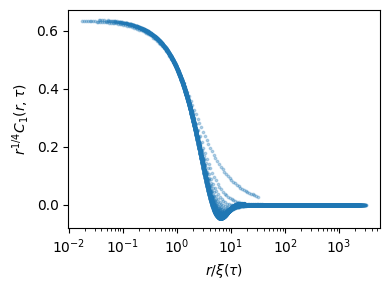

In [282]:
import numpy as np
import matplotlib.pyplot as plt

n = 1  # only n=1
filename = [f for f, nv in zip(tau_filenames, n_values) if nv == n][0]
Pn = np.load(filename)["PP_corr"]

plt.figure(figsize=(4, 3))

for i, tau in enumerate(taus):
    xi_tau = tau**0.5
    y = 4 * Pn[i]
    plt.scatter(r / xi_tau, y * r**0.25, s=3, color="C0", alpha=0.3)

plt.xscale("log")
plt.xlabel(r"$r/\xi(\tau)$")
plt.ylabel(r"$r^{1/4}C_1(r,\tau)$")
plt.tight_layout()
plt.savefig("Felllowship_figure_4.png")
plt.show()